In [1]:
# Cell 1: Setup and Dataset Download Instructions
import os
import warnings
warnings.filterwarnings('ignore')

# Create directory structure
from pathlib import Path
base_dir = Path('LS_LRSI_Data')
directories = ['DEM', 'Rainfall', 'Sentinel2', 'Admin', 'Landslide', 'Soil', 'OSM', 'Processed', 'Output']
for directory in directories:
    (base_dir / directory).mkdir(parents=True, exist_ok=True)

print("✓ Directory structure created")
print(f"Base directory: {base_dir}")


✓ Directory structure created
Base directory: LS_LRSI_Data


In [3]:
!pip install requests rasterio xarray netcdf4 numpy tqdm

   ---------------------------------------- 0.0/21.3 MB ? eta -:--:--
   ---------------------------------------- 0.0/21.3 MB ? eta -:--:--
   ---------------------------------------- 0.3/21.3 MB ? eta -:--:--
    --------------------------------------- 0.5/21.3 MB 1.1 MB/s eta 0:00:19
   - -------------------------------------- 0.8/21.3 MB 1.2 MB/s eta 0:00:18
   - -------------------------------------- 1.0/21.3 MB 1.2 MB/s eta 0:00:17
   -- ------------------------------------- 1.3/21.3 MB 1.1 MB/s eta 0:00:18
   -- ------------------------------------- 1.6/21.3 MB 1.1 MB/s eta 0:00:19
   -- ------------------------------------- 1.6/21.3 MB 1.1 MB/s eta 0:00:19
   --- ------------------------------------ 2.1/21.3 MB 1.1 MB/s eta 0:00:18
   ---- ----------------------------------- 2.4/21.3 MB 1.2 MB/s eta 0:00:17
   ---- ----------------------------------- 2.6/21.3 MB 1.2 MB/s eta 0:00:16
   ----- ---------------------------------- 2.9/21.3 MB 1.2 MB/s eta 0:00:16
   ----- -----------

CHIRPS Rainfall:

In [4]:
#download CHIRPS Rainfall:

import requests

url = "https://data.chc.ucsb.edu/products/CHIRPS/v3.0/daily/final/rnl/2024/chirps-v3.0.rnl.2024.01.01.tif"

response = requests.get(url, stream=True)

print("HTTP status:", response.status_code)
print("File size:", response.headers.get("Content-Length"))

HTTP status: 200
File size: 13409552


In [6]:
from pathlib import Path
import requests

url = "https://data.chc.ucsb.edu/products/CHIRPS/v3.0/daily/final/rnl/2024/chirps-v3.0.rnl.2024.01.01.tif"

output_file = "LS_LRSI_Data/Rainfall/chirps-v3.0.rnl.2024.01.01.tif"

with requests.get(url, stream=True) as r:
    r.raise_for_status()

    with open(output_file, "wb") as f:
        for chunk in r.iter_content(chunk_size=1024 * 1024):
            if chunk:
                f.write(chunk)

print("Downloaded:")
print(output_file)


output_file = Path(output_file)
print("Size:", output_file.stat().st_size / (1024**2), "MB")

Downloaded:
LS_LRSI_Data/Rainfall/chirps-v3.0.rnl.2024.01.01.tif
Size: 12.788345336914062 MB


In [8]:
import rasterio

test_file = "LS_LRSI_Data/Rainfall/chirps-v3.0.rnl.2024.01.01.tif"

with rasterio.open(test_file) as src:
    print("CRS:", src.crs)
    print("Width:", src.width)
    print("Height:", src.height)
    print("Bounds:", src.bounds)
    print("Resolution:", src.res)
    print("NoData:", src.nodata)

CRS: EPSG:4326
Width: 7200
Height: 2400
Bounds: BoundingBox(left=-180.0, bottom=-60.00000178813934, right=180.00000536441803, top=60.0)
Resolution: (0.05000000074505806, 0.05000000074505806)
NoData: None


In [10]:
#Get the Badulla District boundary

import geopandas as gpd

url = (
    "https://www.gisapps.nsdi.gov.lk/server/rest/services/"
    "Srilanka/Boundaries/MapServer/3/query"
    "?where=1%3D1"
    "&outFields=*"
    "&f=geojson"
)

districts = gpd.read_file(url)

print("CRS:", districts.crs)
print("Number of districts:", len(districts))
print("\nColumns:")
print(districts.columns.tolist())

print("\nDistrict names:")
print(districts["district_name"].tolist())

CRS: EPSG:4326
Number of districts: 25

Columns:
['objectid', 'district_name', 'district_code', 'province_name', 'province_code', 'adjusted_area', 'description', 'st_area(shape)', 'st_length(shape)', 'geometry']

District names:
['Ampara', 'Anuradhapura', 'Badulla', 'Batticaloa', 'Colombo', 'Galle', 'Gampaha', 'Hambantota', 'Jaffna', 'Kalutara', 'Kandy', 'Kegalle', 'Kilinochchi', 'Kurunegala', 'Mannar', 'Matale', 'Matara', 'Moneragala', 'Mullaitivu', 'Nuwara Eliya', 'Polonnaruwa', 'Puttalam', 'Ratnapura', 'Trincomalee', 'Vavuniya']


In [11]:
badulla = districts[
    districts["district_name"].str.strip().str.lower() == "badulla"
].copy()

print("Badulla districts found:", len(badulla))
print(badulla[["district_name", "geometry"]])

Badulla districts found: 1
  district_name                                           geometry
2       Badulla  POLYGON ((80.9826 7.61797, 80.98216 7.6181, 80...


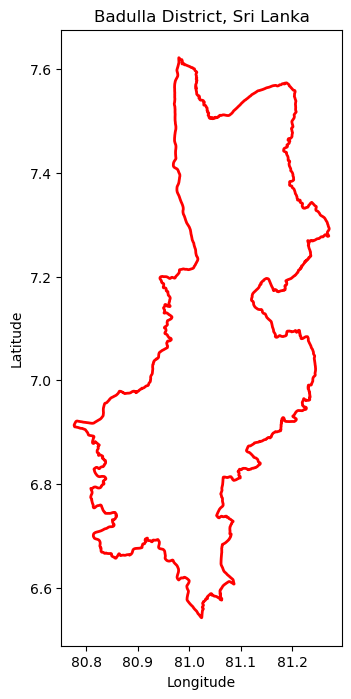

CRS: EPSG:4326
Number of districts: 25
Badulla districts found: 1


In [13]:
#Plot Badulla
import matplotlib.pyplot as plt

fig, ax = plt.subplots(figsize=(8, 8))

badulla.plot(
    ax=ax,
    facecolor="none",
    edgecolor="red",
    linewidth=2
)

ax.set_title("Badulla District, Sri Lanka")
ax.set_xlabel("Longitude")
ax.set_ylabel("Latitude")

plt.show()

print("CRS:", districts.crs)
print("Number of districts:", len(districts))
print("Badulla districts found:", len(badulla))

In [14]:
#Clip CHIRPS rainfall to Badulla

import rasterio
from rasterio.mask import mask
from pathlib import Path

# Your CHIRPS rainfall raster
input_file = Path(
    "LS_LRSI_Data/Rainfall/chirps-v3.0.rnl.2024.01.01.tif"
)

# Output folder
output_folder = Path("LS_LRSI_Data/Rainfall/Badulla")
output_folder.mkdir(parents=True, exist_ok=True)

# Output file
output_file = output_folder / "Badulla_CHIRPS_2024_01_01.tif"

# Open CHIRPS raster
with rasterio.open(input_file) as src:

    # Clip raster using Badulla boundary
    clipped, transform = mask(
        src,
        badulla.geometry,
        crop=True
    )

    # Copy metadata
    metadata = src.meta.copy()

    # Update metadata for clipped raster
    metadata.update({
        "driver": "GTiff",
        "height": clipped.shape[1],
        "width": clipped.shape[2],
        "transform": transform,
        "crs": src.crs
    })

# Save clipped raster
with rasterio.open(output_file, "w", **metadata) as dst:
    dst.write(clipped)

print("✓ Badulla CHIRPS raster created")
print("File:", output_file)

✓ Badulla CHIRPS raster created
File: LS_LRSI_Data\Rainfall\Badulla\Badulla_CHIRPS_2024_01_01.tif


In [15]:
with rasterio.open(output_file) as src:
    print("CRS:", src.crs)
    print("Width:", src.width)
    print("Height:", src.height)
    print("Bounds:", src.bounds)
    print("Resolution:", src.res)
    print("NoData:", src.nodata)

CRS: EPSG:4326
Width: 11
Height: 23
Bounds: BoundingBox(left=80.75000388547778, bottom=6.499999202787876, right=81.30000389367342, top=7.6499992199242115)
Resolution: (0.05000000074505806, 0.05000000074505806)
NoData: None


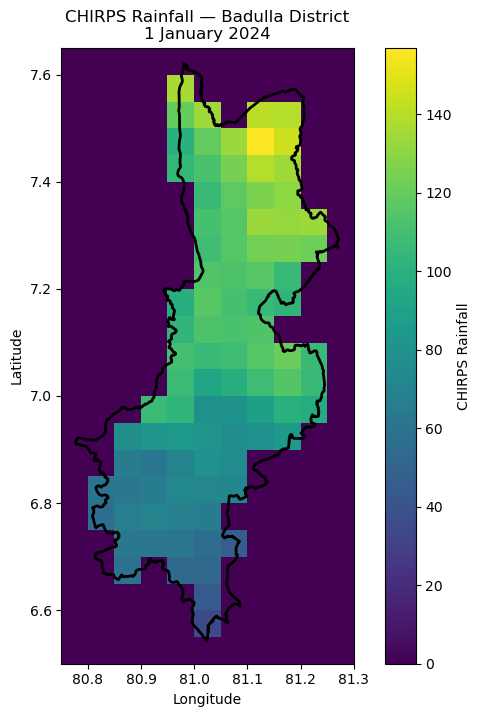

In [16]:
#Plot the rainfall over Badulla
import matplotlib.pyplot as plt
import rasterio

with rasterio.open(output_file) as src:
    rainfall = src.read(1)
    extent = [
        src.bounds.left,
        src.bounds.right,
        src.bounds.bottom,
        src.bounds.top
    ]

fig, ax = plt.subplots(figsize=(8, 8))

im = ax.imshow(
    rainfall,
    extent=extent,
    origin="upper"
)

# Badulla boundary
badulla.boundary.plot(
    ax=ax,
    edgecolor="black",
    linewidth=2
)

plt.colorbar(im, ax=ax, label="CHIRPS Rainfall")
ax.set_title("CHIRPS Rainfall — Badulla District\n1 January 2024")
ax.set_xlabel("Longitude")
ax.set_ylabel("Latitude")

plt.show()

 Administrative Boundaries:

In [17]:
#Filter Badulla from Administrative Boundaries:

from pathlib import Path

admin_folder = Path("LS_LRSI_Data/Admin")

for file in admin_folder.iterdir():
    print(file.name)

lka_admin2.shp


In [18]:
shp_files = list(admin_folder.glob("*.shp"))

print("Shapefiles found:", len(shp_files))

for shp in shp_files:
    print(shp)

Shapefiles found: 1
LS_LRSI_Data\Admin\lka_admin2.shp


In [22]:
import geopandas as gpd

for shp in shp_files:
    try:
        gdf = gpd.read_file(shp)
        print("\nFILE:", shp.name)
        print("Features:", len(gdf))
        print("Columns:", gdf.columns.tolist())
    except Exception as e:
        print("Could not read:", shp.name, e)


FILE: lka_admin2.shp
Features: 25
Columns: ['geometry']


In [26]:
from pathlib import Path

admin_folder = Path("LS_LRSI_Data/Admin")

for f in sorted(admin_folder.iterdir()):
    print(f.name)

lka_admin2.cpg
lka_admin2.dbf
lka_admin2.prj
lka_admin2.shp
lka_admin2.shx


In [27]:
import os

os.environ["SHAPE_RESTORE_SHX"] = "YES"

import geopandas as gpd

shp_file = "LS_LRSI_Data/Admin/lka_admin2.shp"

districts = gpd.read_file(shp_file)

print("CRS:", districts.crs)
print("Number of features:", len(districts))
print("Columns:")
print(districts.columns.tolist())

CRS: EPSG:4326
Number of features: 25
Columns:
['adm2_name', 'adm2_name1', 'adm2_name2', 'adm2_name3', 'adm2_pcode', 'adm1_name', 'adm1_name1', 'adm1_name2', 'adm1_name3', 'adm1_pcode', 'adm0_name', 'adm0_name1', 'adm0_name2', 'adm0_name3', 'adm0_pcode', 'valid_on', 'valid_to', 'area_sqkm', 'version', 'lang', 'lang1', 'lang2', 'lang3', 'center_lat', 'center_lon', 'geometry']


In [28]:
badulla = districts[
    districts["adm2_name"].astype(str).str.strip().str.lower() == "badulla"
].copy()

print("Badulla features:", len(badulla))

Badulla features: 1


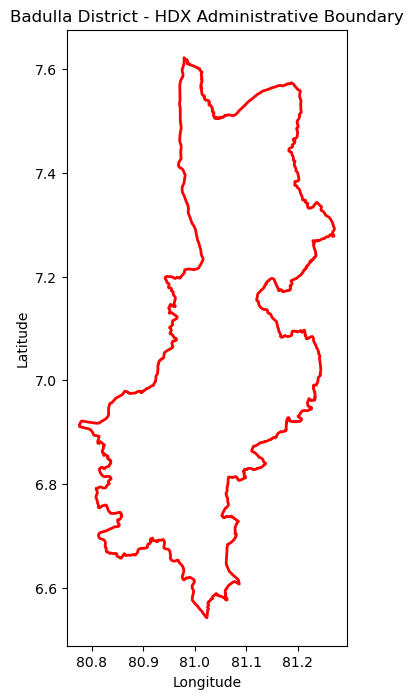

In [29]:
import matplotlib.pyplot as plt

fig, ax = plt.subplots(figsize=(8, 8))

badulla.plot(
    ax=ax,
    facecolor="none",
    edgecolor="red",
    linewidth=2
)

ax.set_title("Badulla District - HDX Administrative Boundary")
ax.set_xlabel("Longitude")
ax.set_ylabel("Latitude")

plt.show()

In [30]:
#save badulla boundary

output_file = "LS_LRSI_Data/Admin/badulla_boundaries.shp"

badulla.to_file(
    output_file,
    driver="ESRI Shapefile"
)

print("Successfully saved:")
print(output_file)

Successfully saved:
LS_LRSI_Data/Admin/badulla_boundaries.shp


OpenStreetMap Data:

In [31]:
import requests
from pathlib import Path

url = "https://download.geofabrik.de/asia/sri-lanka-latest.osm.pbf"

output_folder = Path(r"LS_LRSI_Data\OSM")
output_folder.mkdir(parents=True, exist_ok=True)

output_file = output_folder / "sri-lanka-latest.osm.pbf"

print("Downloading...")
print("Destination:", output_file)

response = requests.get(url, stream=True)
response.raise_for_status()

with open(output_file, "wb") as f:
    for chunk in response.iter_content(chunk_size=1024 * 1024):
        if chunk:
            f.write(chunk)

print("\nDownload completed!")
print("File:", output_file)
print("Size:", round(output_file.stat().st_size / (1024**3), 2), "GB")

Downloading...
Destination: LS_LRSI_Data\OSM\sri-lanka-latest.osm.pbf

Download completed!
File: LS_LRSI_Data\OSM\sri-lanka-latest.osm.pbf
Size: 0.13 GB


Soil Data (SoilGrids):

In [32]:
import geopandas as gpd

badulla_file = r"C:LS_LRSI_Data\Admin\badulla_boundaries.shp"

badulla = gpd.read_file(badulla_file)

print("CRS:", badulla.crs)
print("Features:", len(badulla))
print("Bounds:", badulla.total_bounds)

CRS: EPSG:4326
Features: 1
Bounds: [80.7762751   6.54247409 81.27149177  7.62161334]


In [33]:
!pip install requests

In [37]:
import requests
from pathlib import Path

# ============================================================
# 1. Output folder
# ============================================================

soil_folder = Path(r"LS_LRSI_Data\Soil")
soil_folder.mkdir(parents=True, exist_ok=True)

output_file = soil_folder / "soilgrids_lka.tif"


# ============================================================
# 2. Get Badulla bounding box
# ============================================================

# SoilGrids supports EPSG:4326
badulla_4326 = badulla.to_crs("EPSG:4326")

minx, miny, maxx, maxy = badulla_4326.total_bounds

print("Badulla bounding box:")
print("min X:", minx)
print("min Y:", miny)
print("max X:", maxx)
print("max Y:", maxy)


# ============================================================
# 3. SoilGrids WCS request
# ============================================================

base_url = "https://maps.isric.org/mapserv"

params = {
    "map": "/map/clay.map",
    "SERVICE": "WCS",
    "VERSION": "2.0.1",
    "REQUEST": "GetCoverage",
    "COVERAGEID": "clay_0-5cm_Q0.5",
    "FORMAT": "GEOTIFF_INT16",

    # IMPORTANT: use X and Y, NOT long and lat
    "SUBSET": [
        f"X({minx},{maxx})",
        f"Y({miny},{maxy})"
    ],

    "SUBSETTINGCRS":
        "http://www.opengis.net/def/crs/EPSG/0/4326",

    "OUTPUTCRS":
        "http://www.opengis.net/def/crs/EPSG/0/4326"
}

print("\nRequesting SoilGrids...")
print("Property: Clay")
print("Depth: 0–5 cm")
print("Quantile: Q0.5")

response = requests.get(
    base_url,
    params=params,
    timeout=600
)

print("\nHTTP status:", response.status_code)
print("Content type:", response.headers.get("Content-Type"))

# If the server returns an error, show the actual message
if response.status_code != 200:
    print("\nSoilGrids server response:")
    print(response.text[:3000])

response.raise_for_status()


# ============================================================
# 4. Save GeoTIFF
# ============================================================

with open(output_file, "wb") as f:
    f.write(response.content)

print("\n✓ SoilGrids download completed!")
print("File:", output_file)
print(
    "Size:",
    round(output_file.stat().st_size / (1024 ** 2), 2),
    "MB"
)

Badulla bounding box:
min X: 80.776275102
min Y: 6.542474091000031
max X: 81.27149177299998
max Y: 7.621613340000067

Requesting SoilGrids...
Property: Clay
Depth: 0–5 cm
Quantile: Q0.5

HTTP status: 200
Content type: image/tiff

✓ SoilGrids download completed!
File: LS_LRSI_Data\Soil\soilgrids_lka.tif
Size: 0.1 MB


In [38]:
import rasterio

soil_file = r"LS_LRSI_Data\Soil\soilgrids_lka.tif"

with rasterio.open(soil_file) as src:

    print("CRS:", src.crs)
    print("Width:", src.width)
    print("Height:", src.height)
    print("Bounds:", src.bounds)
    print("Resolution:", src.res)
    print("Bands:", src.count)
    print("Data type:", src.dtypes[0])
    print("NoData:", src.nodata)

CRS: EPSG:4326
Width: 219
Height: 452
Bounds: BoundingBox(left=80.776275102, bottom=6.542474091000032, right=81.271491773, top=7.621613340000067)
Resolution: (0.0022612633378995164, 0.0023874762146018484)
Bands: 1
Data type: int16
NoData: None
